In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import json
import numpy as np
import pandas as pd

# Lectura de parquets 
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
TRAIN_CSV_PATH = "/kaggle/input/asl-fingerspelling/train.csv"

train_df = pd.read_csv(TRAIN_CSV_PATH)

print("Total muestras:", len(train_df))
train_df.head()

## para que entendamos que hay dentro de los parquets, conjunto de líneas que representan un frame identificado a la vedz por un sequence_id.
## como veremos en cada línea del parquet hay muchas coordenadas, de cara, mano izqueirda, mano derecha, etc, a nosotros solo nos va a interesar
#coordenadas de la mano derecha que supuestamente es la que va a representar el lenguaje de signos

## el dataset se divide en parquets por temas de eficiencia y porque sería poco eficiente almacenar todo en un solo parquet, las consultas 
## a las diferentes secuencias serían muy lentas



Total muestras: 67208


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


In [4]:
#división por participantes, trian, evalu i test no deberían compartir los mismos participantes
participants = train_df["participant_id"].unique()
np.random.shuffle(participants)

n = len(participants)

train_ids = participants[:int(0.8 * n)]
val_ids   = participants[int(0.8 * n):int(0.9 * n)]
test_ids  = participants[int(0.9 * n):]

train_df_split = train_df[train_df["participant_id"].isin(train_ids)]
val_df_split   = train_df[train_df["participant_id"].isin(val_ids)]
test_df_split  = train_df[train_df["participant_id"].isin(test_ids)]

print("Train:", len(train_df_split))
print("Val:  ", len(val_df_split))
print("Test: ", len(test_df_split))

Train: 54496
Val:   6209
Test:  6503


In [5]:
VOCAB_PATH = "/kaggle/input/asl-fingerspelling/character_to_prediction_index.json"

with open(VOCAB_PATH) as f:
    original_letter_to_int = json.load(f)

print("Tamaño vocabulario original:", len(original_letter_to_int))
print(list(original_letter_to_int.items()))

Tamaño vocabulario original: 59
[(' ', 0), ('!', 1), ('#', 2), ('$', 3), ('%', 4), ('&', 5), ("'", 6), ('(', 7), (')', 8), ('*', 9), ('+', 10), (',', 11), ('-', 12), ('.', 13), ('/', 14), ('0', 15), ('1', 16), ('2', 17), ('3', 18), ('4', 19), ('5', 20), ('6', 21), ('7', 22), ('8', 23), ('9', 24), (':', 25), (';', 26), ('=', 27), ('?', 28), ('@', 29), ('[', 30), ('_', 31), ('a', 32), ('b', 33), ('c', 34), ('d', 35), ('e', 36), ('f', 37), ('g', 38), ('h', 39), ('i', 40), ('j', 41), ('k', 42), ('l', 43), ('m', 44), ('n', 45), ('o', 46), ('p', 47), ('q', 48), ('r', 49), ('s', 50), ('t', 51), ('u', 52), ('v', 53), ('w', 54), ('x', 55), ('y', 56), ('z', 57), ('~', 58)]


In [6]:
#Añadimos el blank para que CTC pueda detectar cuando hay un cambio de letra
letter_to_int = {}

letter_to_int["<blank>"] = 0

# Desplazamos el resto +1
for char, idx in original_letter_to_int.items():
    letter_to_int[char] = idx + 1

int_to_letter = {v: k for k, v in letter_to_int.items()}

print("Tamaño vocabulario CTC:", len(letter_to_int))
print(list(letter_to_int.items()))

Tamaño vocabulario CTC: 60
[('<blank>', 0), (' ', 1), ('!', 2), ('#', 3), ('$', 4), ('%', 5), ('&', 6), ("'", 7), ('(', 8), (')', 9), ('*', 10), ('+', 11), (',', 12), ('-', 13), ('.', 14), ('/', 15), ('0', 16), ('1', 17), ('2', 18), ('3', 19), ('4', 20), ('5', 21), ('6', 22), ('7', 23), ('8', 24), ('9', 25), (':', 26), (';', 27), ('=', 28), ('?', 29), ('@', 30), ('[', 31), ('_', 32), ('a', 33), ('b', 34), ('c', 35), ('d', 36), ('e', 37), ('f', 38), ('g', 39), ('h', 40), ('i', 41), ('j', 42), ('k', 43), ('l', 44), ('m', 45), ('n', 46), ('o', 47), ('p', 48), ('q', 49), ('r', 50), ('s', 51), ('t', 52), ('u', 53), ('v', 54), ('w', 55), ('x', 56), ('y', 57), ('z', 58), ('~', 59)]


# Encode target

In [7]:
def encode_phrase(phrase, letter_to_int):
    return [letter_to_int[c] for c in phrase if c in letter_to_int]

In [8]:
# Añadir frases codificadas
train_df_split = train_df_split.copy()
val_df_split   = val_df_split.copy()

train_df_split["encoded"] = train_df_split["phrase"].apply(
    lambda x: encode_phrase(x, letter_to_int)
)

val_df_split["encoded"] = val_df_split["phrase"].apply(
    lambda x: encode_phrase(x, letter_to_int)
)

train_df_split[["phrase", "encoded"]].head()

,phrase,encoded
0,3 creekhouse,"[19, 1, 35, 50, 37, 37, 43, 40, 47, 53, 51, 37]"
3,988 franklin lane,"[25, 24, 24, 1, 38, 50, 33, 46, 43, 44, 41, 46..."
4,6920 northeast 661st road,"[22, 25, 18, 16, 1, 46, 47, 50, 52, 40, 37, 33..."
5,www.freem.ne.jp,"[55, 55, 55, 14, 38, 50, 37, 37, 45, 14, 46, 3..."
6,https://jsi.is/hukuoka,"[40, 52, 52, 48, 51, 26, 15, 15, 42, 51, 41, 1..."


# Normalize inputs

In [9]:
MAX_FRAMES = 160
RIGHT_HAND_COLS = None

In [10]:
def read_right_hand_sequence(file_id, sequence_id):
    global RIGHT_HAND_COLS

    path = f"/kaggle/input/asl-fingerspelling/train_landmarks/{file_id}.parquet"
    pq_file = pq.ParquetFile(path)

    # Detectamos columnas una sola vez
    if RIGHT_HAND_COLS is None:
        RIGHT_HAND_COLS = [c for c in pq_file.schema.names if "right_hand" in c]

    table = pq.read_table(
        path,
        filters=[("sequence_id", "=", sequence_id)],
        columns=RIGHT_HAND_COLS
    )

    X = table.to_pandas().values.astype(np.float32)
    return X


In [11]:
def normalize_frames(X, max_frames=MAX_FRAMES):
    T, D = X.shape

    if T > max_frames:
        return X[:max_frames]

    if T < max_frames:
        pad = np.zeros((max_frames - T, D), dtype=np.float32)
        return np.vstack([X, pad])

    return X

In [12]:
row = train_df_split.iloc[0]

X = read_right_hand_sequence(row["file_id"], row["sequence_id"])
Xn = normalize_frames(X)

print("Original:", X.shape)
print("Normalizado:", Xn.shape)
print(Xn[:2])

Original: (123, 63)
Normalizado: (160, 63)
[[ 4.08832341e-01  5.19911826e-01  6.12159431e-01  7.07575560e-01
   7.97312617e-01  4.94709104e-01  5.32817423e-01  5.53556263e-01
   5.66219270e-01  3.91196072e-01  3.46564174e-01  3.29397619e-01
   3.10255587e-01  3.03476274e-01  3.32644910e-01  4.07768786e-01
   4.52753842e-01  2.41266817e-01  3.02986562e-01  3.72976512e-01
   4.13129866e-01  8.28361630e-01  7.97813177e-01  7.29445219e-01
   6.93900228e-01  6.77416861e-01  6.42393529e-01  5.56335509e-01
   5.01642942e-01  4.52985287e-01  6.48080289e-01  5.52678347e-01
   4.90614533e-01  4.39064264e-01  6.80147648e-01  6.45134449e-01
   6.97051287e-01  7.39249945e-01  7.28378952e-01  7.30377913e-01
   7.70164847e-01  7.98620582e-01  1.43825059e-06 -6.52954429e-02
  -9.94892642e-02 -1.34329841e-01 -1.69375926e-01 -9.35534909e-02
  -1.57288164e-01 -1.93132892e-01 -2.17872515e-01 -1.09474696e-01
  -1.96916208e-01 -2.45855495e-01 -2.69147664e-01 -1.29743367e-01
  -2.51500934e-01 -2.78686613e-01

In [13]:
X.shape

(123, 63)

## Center hand

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
X[:,0]

array([0.40883234,        nan,        nan, 0.39866304,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan, 0.4192902 , 0.39876372, 0.42021275,
       0.3867662 , 0.4162758 , 0.39987853, 0.39559555, 0.40540552,
       0.39832422, 0.38958845, 0.39503154, 0.40158984, 0.4036588 ,
       0.41382727, 0.41468585, 0.41416252, 0.42203447, 0.4208882 ,
       0.41031012, 0.3857881 , 0.36503744, 0.34279814, 0.3291641 ,
       0.3277529 , 0.32596987, 0.32103583,        nan,        nan,
              nan,        nan, 0.2812801 , 0.23981842, 0.22464696,
       0.20265597, 0.19723484, 0.19597493, 0.20674579, 0.22094925,
       0.25327137, 0.26754296, 0.2961455 , 0.336138  , 0.3450714 ,
       0.3458939 , 0.34926668, 0.3534579 , 0.36983955, 0.38783193,
       0.3895693 , 0.38472137, 0.40469158, 0.4276709 , 0.44304633,
       0.45007104, 0.44424865, 0.44357753, 0.4219007 , 0.39660338,
       0.34517616,        nan,        nan,        nan,        

(array([ 5.,  2.,  2.,  2.,  2.,  8.,  4., 12., 16.,  5.]),
 array([0.19597493, 0.22138454, 0.24679415, 0.27220374, 0.29761338,
        0.32302296, 0.3484326 , 0.37384218, 0.39925182, 0.4246614 ,
        0.45007104]),
 <BarContainer object of 10 artists>)

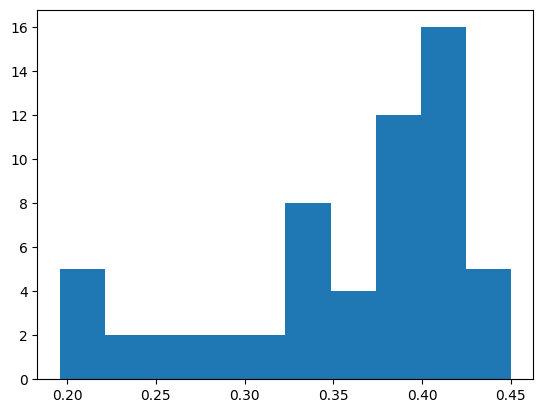

In [16]:
plt.hist(X[:,0])

In [17]:
def read_right_hand_pandas(file_id, sequence_id):
    global RIGHT_HAND_COLS

    path = f"/kaggle/input/asl-fingerspelling/train_landmarks/{file_id}.parquet"
    pq_file = pq.ParquetFile(path)

    # Detectamos columnas una sola vez
    if RIGHT_HAND_COLS is None:
        RIGHT_HAND_COLS = [c for c in pq_file.schema.names if "right_hand" in c]

    table = pq.read_table(
        path,
        filters=[("sequence_id", "=", sequence_id)],
        columns=RIGHT_HAND_COLS
    )

    X = table.to_pandas()
    return X

In [18]:
X_pd = read_right_hand_pandas(row["file_id"], row["sequence_id"])
X_pd

,x_right_hand_0,x_right_hand_1,x_right_hand_2,x_right_hand_3,x_right_hand_4,x_right_hand_5,x_right_hand_6,x_right_hand_7,x_right_hand_8,x_right_hand_9,...,z_right_hand_11,z_right_hand_12,z_right_hand_13,z_right_hand_14,z_right_hand_15,z_right_hand_16,z_right_hand_17,z_right_hand_18,z_right_hand_19,z_right_hand_20
0,0.408832,0.519912,0.612159,0.707576,0.797313,0.494709,0.532817,0.553556,0.566219,0.391196,...,-0.245855,-0.269148,-0.129743,-0.251501,-0.278687,-0.266530,-0.152852,-0.257519,-0.275822,-0.266876
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.398663,0.523662,0.638807,0.744236,0.832567,0.538486,0.564302,0.581011,0.597674,0.441541,...,-0.370770,-0.408097,-0.185217,-0.325494,-0.343373,-0.328294,-0.203126,-0.315719,-0.326104,-0.314282
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


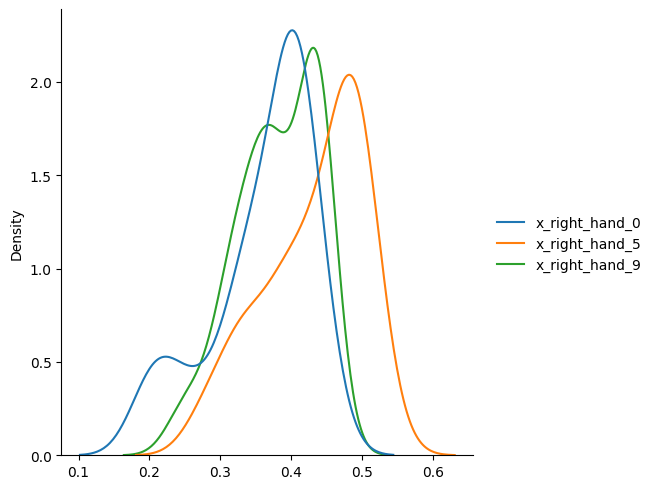

In [19]:
#sns.displot(X_pd[['x_right_hand_0', 'y_right_hand_0', 'z_right_hand_0']], kind='kde')
#sns.displot(X_pd[[f"x_right_hand_{i}" for i in range(0,5)]], kind='kde')
sns.displot(X_pd[[f"x_right_hand_{i}" for i in [0, 5, 9]]], kind='kde')

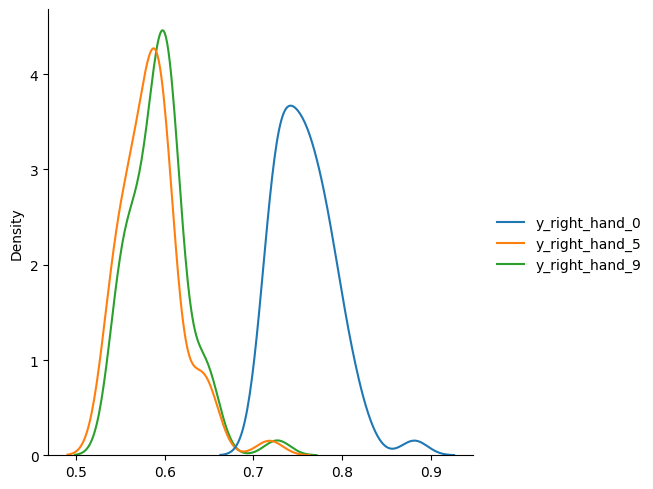

In [20]:
sns.displot(X_pd[[f"y_right_hand_{i}" for i in [0,5,9]]], kind='kde')

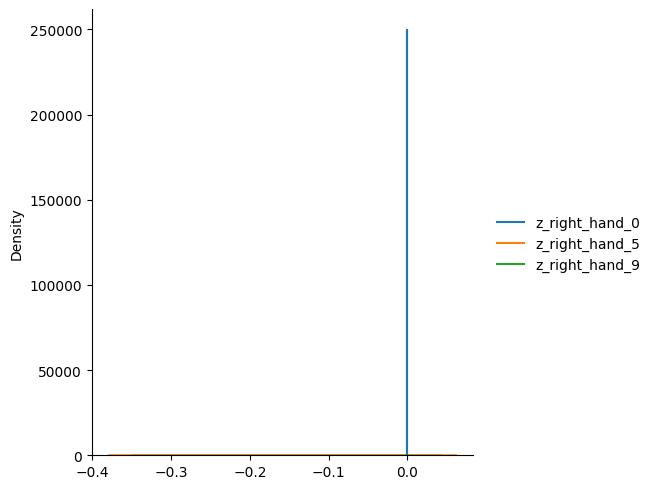

In [21]:
sns.displot(X_pd[[f"z_right_hand_{i}" for i in [0,5,9]]], kind='kde')

In [22]:
X_pd[~X_pd["x_right_hand_0"].isna()][[f"z_right_hand_{i}" for i in [0,5,9]]]

,z_right_hand_0,z_right_hand_5,z_right_hand_9
0,1.438251e-06,-0.093553,-0.109475
3,1.699293e-06,-0.158306,-0.171088
12,1.633807e-06,-0.115064,-0.132532
13,1.511415e-06,-0.093985,-0.114926
14,1.164981e-06,-0.073426,-0.087533
15,8.864697e-07,-0.012785,-0.032768
16,1.110499e-06,-0.033185,-0.053282
17,1.055618e-06,-0.035660,-0.055608
18,1.200176e-06,-0.057349,-0.078615
19,7.140646e-07,-0.048422,-0.068079


In [23]:
row = train_df_split.iloc[0]
file_id, sequence_id = row["file_id"], row["sequence_id"]

path = f"/kaggle/input/asl-fingerspelling/train_landmarks/{file_id}.parquet"

In [24]:
pq_file = pq.ParquetFile(path)

In [25]:
[c for c in pq_file.schema.names if "right_hand" in c]

['x_right_hand_0',
 'x_right_hand_1',
 'x_right_hand_2',
 'x_right_hand_3',
 'x_right_hand_4',
 'x_right_hand_5',
 'x_right_hand_6',
 'x_right_hand_7',
 'x_right_hand_8',
 'x_right_hand_9',
 'x_right_hand_10',
 'x_right_hand_11',
 'x_right_hand_12',
 'x_right_hand_13',
 'x_right_hand_14',
 'x_right_hand_15',
 'x_right_hand_16',
 'x_right_hand_17',
 'x_right_hand_18',
 'x_right_hand_19',
 'x_right_hand_20',
 'y_right_hand_0',
 'y_right_hand_1',
 'y_right_hand_2',
 'y_right_hand_3',
 'y_right_hand_4',
 'y_right_hand_5',
 'y_right_hand_6',
 'y_right_hand_7',
 'y_right_hand_8',
 'y_right_hand_9',
 'y_right_hand_10',
 'y_right_hand_11',
 'y_right_hand_12',
 'y_right_hand_13',
 'y_right_hand_14',
 'y_right_hand_15',
 'y_right_hand_16',
 'y_right_hand_17',
 'y_right_hand_18',
 'y_right_hand_19',
 'y_right_hand_20',
 'z_right_hand_0',
 'z_right_hand_1',
 'z_right_hand_2',
 'z_right_hand_3',
 'z_right_hand_4',
 'z_right_hand_5',
 'z_right_hand_6',
 'z_right_hand_7',
 'z_right_hand_8',
 'z_right

In [26]:
def count_valid_frames(X):
    # Un frame es válido si NO todo es NaN
    return np.sum(~np.all(np.isnan(X), axis=1))

In [27]:

class ASLRightHandDataset(Dataset):
    def __init__(self, df, max_frames=160):
        self.df = df.reset_index(drop=True)
        self.max_frames = max_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
    
        X_raw = read_right_hand_sequence(
            row["file_id"],
            row["sequence_id"]
        )  
    
        input_len = count_valid_frames(X_raw)
    
        Y = torch.tensor(row["encoded"], dtype=torch.long)
        target_len = len(Y)

        if input_len < target_len:
            return None

    
        X = normalize_frames(X_raw, self.max_frames)
    
        X = np.nan_to_num(X, nan=0.0)
    
        X = torch.tensor(X, dtype=torch.float32)
    
        input_len = min(input_len, self.max_frames)
    
        return X, Y, input_len, target_len


In [28]:
def collate_fn(batch):
    # Quitamos ejemplos inválidos (None)
    batch = [b for b in batch if b is not None]

    # Si todo el batch era inválido, devolvemos None
    if len(batch) == 0:
        return None

    Xs = []
    Ys = []
    in_lens = []
    tar_lens = []

    for X, Y, in_len, tar_len in batch:
        Xs.append(X)
        Ys.append(Y)
        in_lens.append(in_len)
        tar_lens.append(tar_len)

    Xs = torch.stack(Xs)
    Ys = torch.cat(Ys)
    in_lens = torch.tensor(in_lens, dtype=torch.long)
    tar_lens = torch.tensor(tar_lens, dtype=torch.long)

    return Xs, Ys, in_lens, tar_lens


In [29]:
train_df_tiny = train_df_split.sample(200, random_state=0)
train_dataset_tiny = ASLRightHandDataset(train_df_tiny)

train_loader_tiny = DataLoader(
    train_dataset_tiny,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

X, Y, in_len, tar_len = next(iter(train_loader_tiny))

print("X:", X.shape)          # (B, 160, 63)
print("Y:", Y.shape)          # (sum of target lengths)
print("in_len:", in_len)
print("tar_len:", tar_len)


X: torch.Size([4, 160, 63])
Y: torch.Size([88])
in_len: tensor([160,  67, 126,  39])
tar_len: tensor([29, 13, 22, 24])


In [30]:

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x):
        out, _ = self.rnn(x)        # (B, T, H)
        out = self.classifier(out)  # (B, T, C)
        out = self.log_softmax(out)
        out = out.permute(1, 0, 2)  # (T, B, C) para CTC
        return out


In [31]:
class EmbeddedRNN(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size, num_classes):
        super().__init__()

        self.embedding = nn.Linear(input_size, embed_size)

        self.rnn = nn.RNN(
            input_size=embed_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x):

        x = self.embedding(x)       
        out, _ = self.rnn(x)      
        out = self.classifier(out)  
        out = self.log_softmax(out)
        out = out.permute(1, 0, 2)  

        return out

In [32]:
num_classes = len(letter_to_int)


model = SimpleRNN(
    input_size=63,
    hidden_size=128,
    num_classes=num_classes
).to(DEVICE)

In [33]:
model = EmbeddedRNN(
    input_size=63,         
    embed_size=128,         
    hidden_size=128,
    num_classes=len(letter_to_int)
).to(DEVICE)

In [34]:
model.eval()

with torch.no_grad():
    outputs = model(X.to(DEVICE))

print(outputs.shape)


torch.Size([160, 4, 60])


In [35]:

criterion = nn.CTCLoss(
    blank=letter_to_int["<blank>"],
    zero_infinity=True
)

loss = criterion(
    outputs,    # (T, B, C)
    Y.to(DEVICE),
    in_len,
    tar_len
)

print("CTC loss:", loss.item())

CTC loss: 15.40089225769043


In [36]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in loader:

        if batch is None:
            continue

        X, Y, input_lens, target_lens = batch

        X = X.to(device)
        Y = Y.to(device)
        input_lens = input_lens.to(device)
        target_lens = target_lens.to(device)

        optimizer.zero_grad()

        outputs = model(X)  # (T, B, C)

        loss = criterion(
            outputs,
            Y,
            input_lens,
            target_lens
        )

        loss.backward()


        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches

    return avg_loss



In [37]:
num_epochs = 3
train_losses = []
grad_norms = []
optimizer = optim.Adam(model.parameters(), lr=1e-3)


for epoch in range(num_epochs):
    loss = train_one_epoch(
        model,
        train_loader_tiny,
        optimizer,
        criterion,
        DEVICE
    )
    train_losses.append(loss)
    print(f"Epoch {epoch+1}: loss = {loss:.2f}")

Epoch 1: loss = 5.50
Epoch 2: loss = 3.81
Epoch 3: loss = 3.77


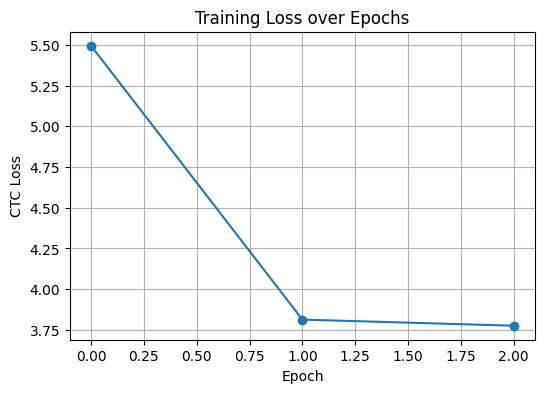

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()
